In [1]:
import pandas as pd
import numpy as np
import squarify
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random
import matplotlib.colors as mcolors
import re
import plotly.express as px  # for sunburst chart
import seaborn as sns

In [2]:
dataFrame = pd.read_csv("processed_education.csv")

## 1. Plotting Distribution of Degrees Among Data Scientists on Pie Chart

In [46]:
def extract_degree(field):
    degrees = re.findall(r'\b(MS|BS|PhD|Master of Science|Bachelor of Science|Doctor of Philosophy)\b', field)
    return ', '.join(degrees) if degrees else None

dataFrame['Degrees'] = dataFrame['Field_of_Study'].apply(lambda x: extract_degree(str(x)))

dataFrame = dataFrame.dropna(subset=['Degrees'])

dataFrame.to_csv("updated_file_with_degrees.csv", index=False)


In [47]:
df = pd.read_csv("updated_file_with_degrees.csv")

In [48]:
df['Degrees'] = df['Degrees'].replace({
    'BS': 'Bachelors',
    'Bachelor of Science, BS': 'Bachelors',
    'Bachelor of Science' : 'Bachelors',
    'PhD': 'PhD',
    'PhD, PhD': 'PhD',
    'Doctor of Philosophy, PhD': 'Post Doc',
    'Master of Science, MS': 'Masters',
    'Master of Science' : 'Masters',
    'Doctor of Philosophy' : 'Post Doc',
    'MS' : 'Masters'
})

df.to_csv("updated_file_with_degrees.csv", index=False)

In [49]:
item_count = df["Degrees"].value_counts()

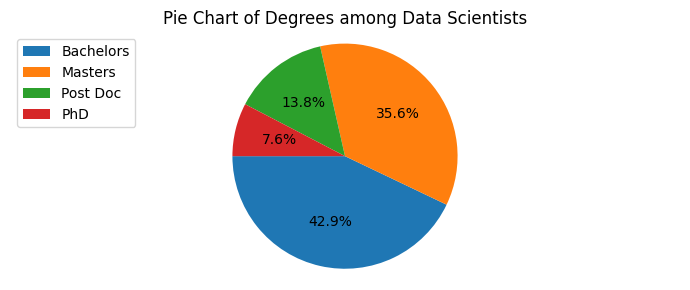

In [64]:
plt.figure(figsize=(7,3))
plt.pie(item_count, autopct='%1.1f%%', startangle=180)
plt.legend(loc='upper left', labels=item_count.index)
plt.axis('equal')
plt.title("Pie Chart of Degrees among Data Scientists")
plt.tight_layout()
plt.savefig("Figure 1.png")

## 2. Plotting Jobs among Data Scientists on a Count Plot

In [3]:
dataFrame = pd.read_csv("cleaned_experience.csv")

In [4]:
item_count = dataFrame["Job Title"].value_counts()

In [5]:
filtered_job_titles = item_count[item_count >= 10].index.tolist()
filtered_dataFrame = dataFrame[dataFrame["Job Title"].isin(filtered_job_titles)]
filtered_dataFrame["Job Title"].value_counts()

Job Title
Data Scientist              261
Senior Data Scientist        70
Data Analyst                 44
Research Assistant           27
Software Engineer            21
Lead Data Scientist          17
Intern                       17
Data Science Intern          16
Data Engineer                12
Researcher                   11
Principal Data Scientist     10
Name: count, dtype: int64

C:\Users\Aneeq\AppData\Local\Temp\ipykernel_6496\518752364.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Job Title', data=filtered_dataFrame, palette='Set1', order=updated_counts.index)


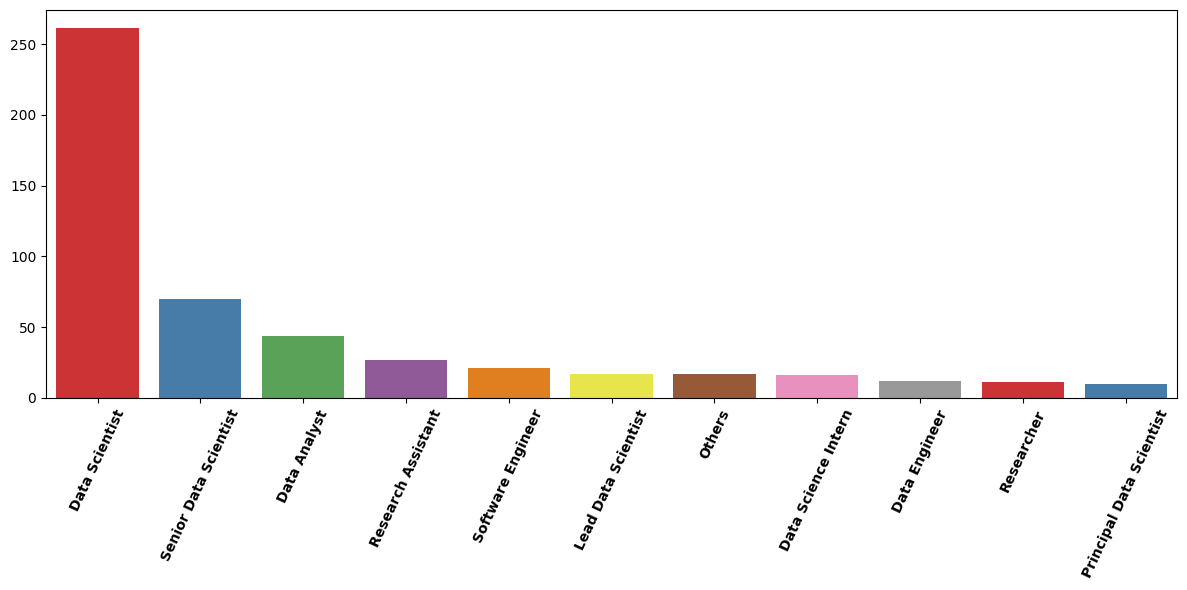

In [7]:
job_title_counts = filtered_dataFrame['Job Title'].value_counts()

other_jobs = job_title_counts[job_title_counts.index.str.len() < 10].index.tolist()

filtered_dataFrame.loc[filtered_dataFrame['Job Title'].isin(other_jobs), 'Job Title'] = 'Others'

updated_counts = filtered_dataFrame['Job Title'].value_counts()

plt.figure(figsize=(12, 6))
sns.countplot(x='Job Title', data=filtered_dataFrame, palette='Set1', order=updated_counts.index)
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=65, fontweight='bold')  # Adding fontweight='bold' to make the x-axis labels bold
plt.tight_layout()
plt.savefig('Figure 2.png')
plt.show()


## 3. Plotting Company Titles on Line Chart

In [9]:
dataFrame = pd.read_csv("cleaned_experience.csv")

company_title = dataFrame["Company Title"].str.split("·", n=1).str[1].tolist()
dataFrame["Job Type"] = company_title
dataFrame.to_csv("cleaned_experience.csv")
company_title = dataFrame["Company Title"].str.split("·", n=1).str[0].tolist()
dataFrame["Company Title"] = company_title
dataFrame.to_csv("cleaned_experience.csv")

In [10]:
item_count = dataFrame["Company Title"].value_counts()

In [11]:
item_count

Company Title
Rakuten                                               13
Self-employed                                          8
IBM                                                    7
Microsoft                                              7
Coupang                                                6
                                                      ..
HutchinsonHutchinson                                   1
Mobile Devices IngenierieMobile Devices Ingenierie     1
ThalesThales                                           1
CEA ListCEA List                                       1
Sir Leckraz Teelock SSSSir Leckraz Teelock SSS         1
Name: count, Length: 1473, dtype: int64

In [12]:
filtered_company_titles = item_count[item_count >= 5].index.tolist()
filtered_dataFrame = dataFrame[dataFrame["Company Title"].isin(filtered_company_titles)]
sorted_companies = filtered_dataFrame["Company Title"].value_counts().index

C:\Users\Aneeq\AppData\Local\Temp\ipykernel_6496\3295774734.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


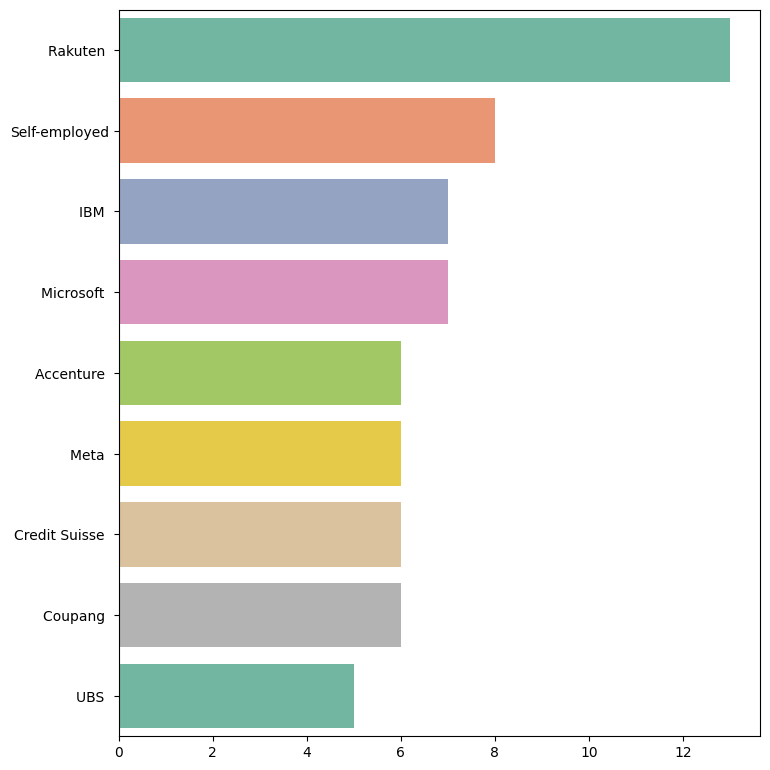

In [13]:
plt.figure(figsize=(8, 8))
sns.countplot(
    y="Company Title",
    data=filtered_dataFrame,
    order=sorted_companies,
    palette=sns.color_palette("Set2", n_colors=len(filtered_company_titles))
)
plt.xlabel('Frequency')
plt.tight_layout()
plt.xlabel('')
plt.ylabel('')
plt.savefig("Figure 3.png")
plt.show()

## 4. Plotting Word Cloud on Summaries 

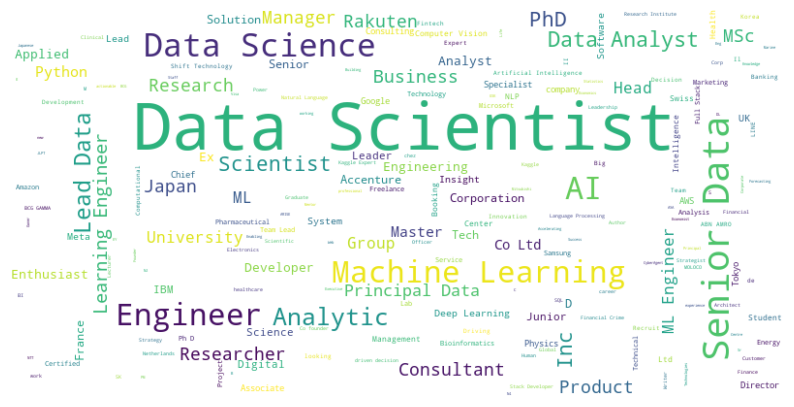

In [216]:
df = pd.read_csv("profile_data.csv")

text = ' '.join(df['Summary'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig("Figure 4.png")

## 5. Plotting Skills on Treemap

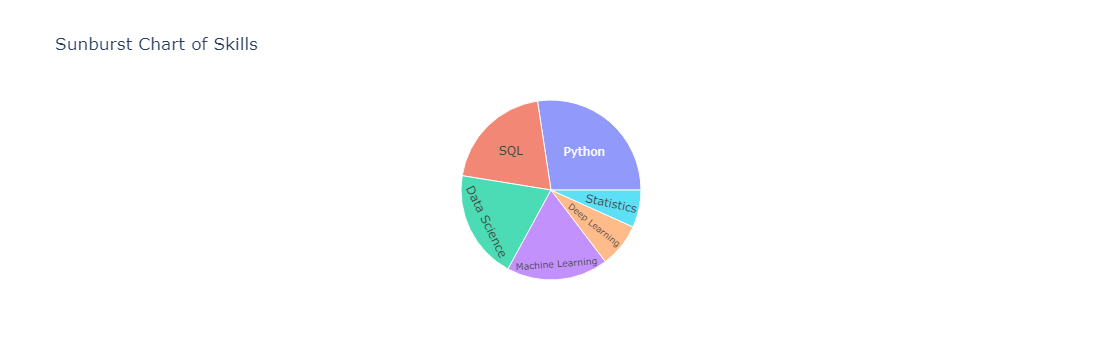

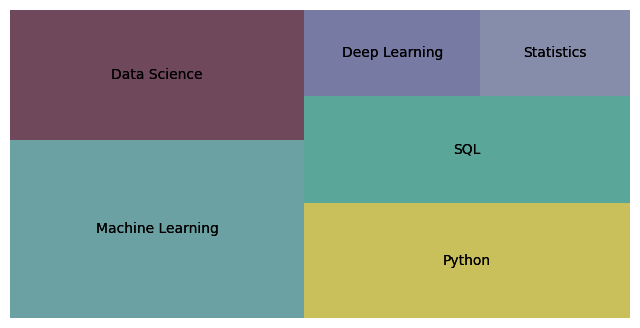

In [15]:
df = pd.read_csv("profile_data.csv")

skill_keywords = ['Machine Learning', 'Data Science', 'Python', 'SQL', 'Deep Learning', 'Statistics']

def extract_skills(text):
    if isinstance(text, str):
        return [word for word in skill_keywords if word in text]
    else:
        return []

df['Skills'] = df['About'].apply(extract_skills)

df = df[df['Skills'].apply(len) > 0]

sunburst_data = df.explode('Skills')

fig = px.sunburst(sunburst_data, path=['Skills'], title='Sunburst Chart of Skills')
fig.show()

colors = random.sample(list(mcolors.CSS4_COLORS.values()), len(df['Skills'].explode().unique()))
plt.figure(figsize=(8, 4))
squarify.plot(sizes=df['Skills'].explode().value_counts(), label=df['Skills'].explode().unique(),
              alpha=0.6, color=colors)

squarify.plot(sizes=df['Skills'].explode().value_counts(), label=df['Skills'].explode().unique(), alpha=0.6)
plt.axis('off')
plt.savefig("Figure 5.png")